In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plts

In [3]:
drinking_df = pd.read_csv("smoking_driking_dataset_Ver01.csv")
drinking_df

,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
991341,Male,45,175,80,92.1,1.5,1.5,1.0,1.0,114.0,...,125.0,132.0,15.0,1.0,1.0,26.0,36.0,27.0,1.0,N
991342,Male,35,170,75,86.0,1.0,1.5,1.0,1.0,119.0,...,84.0,45.0,15.8,1.0,1.1,14.0,17.0,15.0,1.0,N
991343,Female,40,155,50,68.0,1.0,0.7,1.0,1.0,110.0,...,77.0,157.0,14.3,1.0,0.8,30.0,27.0,17.0,3.0,Y
991344,Male,25,175,60,72.0,1.5,1.0,1.0,1.0,119.0,...,73.0,53.0,14.5,1.0,0.8,21.0,14.0,17.0,1.0,N


In [4]:
num_duplicates = drinking_df.duplicated().sum()
num_total = drinking_df.shape[0]
num_unique = num_total - num_duplicates
print(f"Prosent beholdt: {(num_unique / num_total) * 100:.10f}%")
drinking_df_unique = drinking_df.drop_duplicates()

Prosent beholdt: 99.9973773032%


In [5]:
import numpy as np
import pandas as pd

df = drinking_df_unique.copy()

cat_cols = ["sex", "SMK_stat_type_cd", "DRK_YN", "urine_protein", "hear_left", "hear_right"]
no_log = ["SMK_stat_type_cd", "urine_protein", "hemoglobin", "hear_right", "hear_left", "weight", "height", "age"]

df_log = df.copy()

def transform_with_optional_log(df, col, allow_log=True):

    global df_log

    if col not in df.columns:
        return

    data = df[col].dropna()
    if data.empty:
        return

    if col in cat_cols:
        return

    if allow_log and (data > 0).all():
        log_series = np.log10(data)     
        df_log.loc[log_series.index, col] = log_series

for col in df.columns:
    allow_log = (col not in no_log and col not in cat_cols)
    transform_with_optional_log(df, col, allow_log=allow_log)



In [6]:
import pandas as pd
import numpy as np
from scipy.stats import zscore

df = df_log.copy()

columns_to_check = [
    "age", "height", "weight", "waistline",
    "sight_left", "sight_right",
    "SBP", "DBP", "BLDS",
    "tot_chole", "HDL_chole", "LDL_chole", "triglyceride",
    "hemoglobin", "serum_creatinine", "SGOT_AST", "SGOT_ALT", "gamma_GTP",
]

# Beregn z-scores per kolonne (NaN ignoreres i sammenligningen under)
z_scores = df[columns_to_check].apply(zscore)

# Behold rader der alle valgte kolonner har |z| <= 3
mask = (np.abs(z_scores) <= 3).all(axis=1)
df_clean = df[mask].copy()

print(f"Rows before: {len(df)}, after outlier removal: {len(df_clean)}")

# df_clean er nå datasettet uten outliers etter z-score-kriteriet


Rows before: 991320, after outlier removal: 877018


In [7]:

df_clean["sex"] = df_clean["sex"].map({"Male": 0, "Female": 1})
df_clean["DRK_YN"] = df_clean["DRK_YN"].map({"N": 0, "Y": 1})

df_clean = df_clean.round(1)

df_clean.to_csv("drinking_df_encoded.csv", index=False)

print("done")

done


In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# --- 1) Les data ---
df = pd.read_csv("drinking_df_encoded.csv")

# Sikre numeriske typer der mulig
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="ignore")

# --- 2) Lag BMI og fjern height/weight ---
if {"height", "weight"}.issubset(df.columns):
    valid_h = pd.to_numeric(df["height"], errors="coerce") > 0
    df.loc[valid_h, "BMI"] = df.loc[valid_h, "weight"] / (df.loc[valid_h, "height"] / 100.0) ** 2
    df = df.drop(columns=["height", "weight"], errors="ignore")

# --- 3) Aldersgrupper → tall i [0,1] ---
bins   = [15, 24, 44, 66, 79, np.inf]              # 16–24, 25–44, 45–66, 67–79, 80+
labels = ["16-24", "25-44", "45-66", "67-79", "80+"]
if "age" in df.columns:
    age_cat = pd.cut(df["age"], bins=bins, labels=labels, include_lowest=True, right=True)
    idx_map = {lab: i for i, lab in enumerate(labels)}  # 0..4
    age_idx = age_cat.map(idx_map).astype(float)
    df["age_group_scaled"] = age_idx / (len(labels) - 1)  # → [0,1]
    df = df.drop(columns=["age"], errors="ignore")

# --- 4) Skaler alle andre numeriske kolonner til [0,1] (behold age_group_scaled som er ferdig skalert) ---
num_cols = df.select_dtypes(include=[float, int]).columns.tolist()
cols_to_scale = [c for c in num_cols if c != "age_group_scaled"]

if cols_to_scale:
    scaler = MinMaxScaler()
    df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# --- 5) Flytt DRK_YN (target) til siste kolonne ---
if "DRK_YN" in df.columns:
    df = df[[c for c in df.columns if c != "DRK_YN"] + ["DRK_YN"]]

# --- 6) Lagre ---
out_path = "drinking_df_bmi_agegroup_scaled.csv"
df.to_csv(out_path, index=False)
print(f"✅ Done -> {out_path}")



/tmp/ipykernel_81629/1573980676.py:10: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[c] = pd.to_numeric(df[c], errors="ignore")


✅ Done -> drinking_df_bmi_agegroup_scaled.csv


Komponenter som kreves for forklart varians:
 - 100%: 22 komponenter
 -  90%: 12 komponenter
 -  80%: 8 komponenter


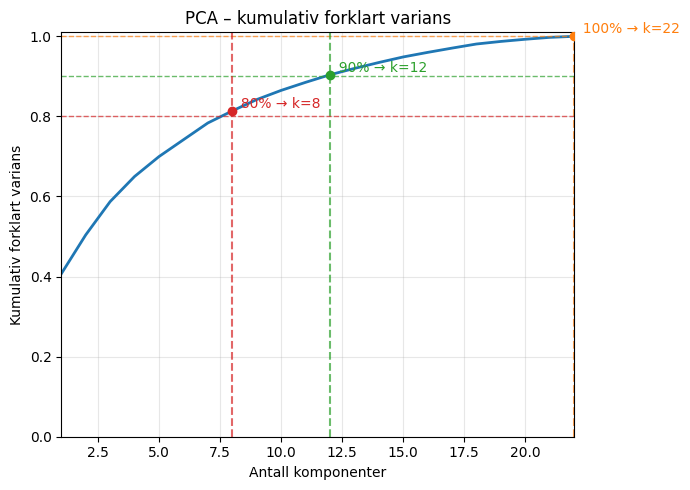

✅ Lagret PCA-transformert data (8 komponenter, ≈80% varians) → drinking_df_pca.csv


In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# ---- Konfig ----
CSV_IN   = "drinking_df_bmi_agegroup_scaled.csv"
CSV_OUT  = "drinking_df_pca.csv"
TARGET   = "DRK_YN"
VAR_LEVELS = [1.00, 0.90, 0.80]   # 100%, 90%, 80%
SAVE_VARIANCE = 0.80              # hvilken forklart varians skal eksporteres til CSV

# ---- Les data (forutsatt skalert) ----
df = pd.read_csv(CSV_IN)
X = df.drop(columns=[TARGET])
y = df[TARGET].values

# ---- Full PCA (alle komponenter) for å få hele kurven ----
pca_full = PCA(n_components=None, random_state=42)
X_full = pca_full.fit_transform(X)

explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

# ---- Finn #komponenter for 100%, 90% og 80% ----
comp_counts = {}
for lvl in VAR_LEVELS:
    # searchsorted finner første indeks der kumulativ >= nivå
    k = int(np.searchsorted(cum_explained, lvl, side="left")) + 1  # +1 pga 0-indeksering → antall komponenter
    comp_counts[int(lvl*100)] = k

print("Komponenter som kreves for forklart varians:")
for pct, k in comp_counts.items():
    print(f" - {pct:>3}%: {k} komponenter")

# ---- Plott: hele kumulative varianskurven + markører ----
plt.figure(figsize=(7, 5))
plt.plot(np.arange(1, len(cum_explained)+1), cum_explained, linewidth=2)
plt.xlabel("Antall komponenter")
plt.ylabel("Kumulativ forklart varians")
plt.title("PCA – kumulativ forklart varians")

# Marker nivåene 100%, 90%, 80%
colors = {100: "C1", 90: "C2", 80: "C3"}
for pct, k in comp_counts.items():
    yval = cum_explained[k-1]
    # vertikal linje ved k, horisontal linje ved pct
    plt.axvline(k, linestyle="--", color=colors[pct], alpha=0.7)
    plt.axhline(pct/100.0, linestyle="--", color=colors[pct], alpha=0.7, linewidth=1)
    # liten annotasjon
    plt.scatter([k], [yval], color=colors[pct], zorder=3)
    plt.text(k, yval, f"  {pct}% → k={k}", va="bottom", color=colors[pct])

plt.ylim(0, 1.01)
plt.xlim(1, len(cum_explained))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Lag og lagre PCA-datasett for valgt SAVE_VARIANCE ----
k_save = comp_counts[int(SAVE_VARIANCE*100)]
# Lag ny PCA med n_components = k_save og transformer
pca = PCA(n_components=k_save, random_state=42)
X_pca = pca.fit_transform(X)

pca_cols = [f"PC{i+1}" for i in range(k_save)]
df_pca = pd.DataFrame(X_pca, columns=pca_cols)
df_pca[TARGET] = y
df_pca.to_csv(CSV_OUT, index=False)

print(f" Saved PCA-transformed data. ({k_save} komponenter, ≈{int(SAVE_VARIANCE*100)}% var) → {CSV_OUT}")



In [1]:
# === Celle 1 (ALLTID lese fra PCA_CSV) ===
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Reproduserbarhet
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Filnavn
PCA_CSV = "drinking_df_pca.csv"   # må finnes; inneholder PC1..PCk + DRK_YN
NPZ_OUT = "pca_split_cache.npz"   # cache for treningscellen
TARGET = "DRK_YN"

# 1) Les alltid fra PCA_CSV (ingen ny PCA-kjøring her)
assert os.path.exists(PCA_CSV), f"Mangler {PCA_CSV} – lag denne i en separat prosess før du kjører."
df_pca = pd.read_csv(PCA_CSV)
assert TARGET in df_pca.columns, f"Mangler target-kolonne '{TARGET}' i {PCA_CSV}"

y = df_pca[TARGET].astype(int).values
X_pca = df_pca.drop(columns=[TARGET]).astype(np.float32).values

print(f"✅ Lastet PCA-data fra {PCA_CSV}: {X_pca.shape[0]} rader, {X_pca.shape[1]} komponenter.")

# 2) Stratified train/test-splitt
idx = np.arange(len(y))
idx_train, idx_test = train_test_split(
    idx, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
Xp_train, Xp_test = X_pca[idx_train], X_pca[idx_test]
y_train, y_test   = y[idx_train],      y[idx_test]

# 3) Cache til .npz for Celle 2
np.savez_compressed(
    NPZ_OUT,
    Xp_train=Xp_train, Xp_test=Xp_test,
    y_train=y_train,   y_test=y_test,
    random_state=np.array([RANDOM_STATE], dtype=np.int32)
)

print(f"💾 Cachet datasplitt til {NPZ_OUT}")
print(f"   Train: {Xp_train.shape}, Test: {Xp_test.shape}")



✅ Lastet PCA-data fra drinking_df_pca.csv: 877018 rader, 8 komponenter.
💾 Cachet datasplitt til pca_split_cache.npz
   Train: (701614, 8), Test: (175404, 8)


2025-10-25 15:32:14.858578: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Lastet cache: Train (701614, 8), Test (175404, 8)

=== Gaussian Naive Bayes (PCA) ===
Accuracy: 0.6942
ROC AUC: 0.7475
Confusion matrix:
 [[59619 27703]
 [25936 62146]]
Classification report:
               precision    recall  f1-score   support

           0     0.6968    0.6827    0.6897     87322
           1     0.6917    0.7055    0.6985     88082

    accuracy                         0.6942    175404
   macro avg     0.6943    0.6941    0.6941    175404
weighted avg     0.6942    0.6942    0.6942    175404



I0000 00:00:1761399137.051813   93737 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6063 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080, pci bus id: 0000:01:00.0, compute capability: 7.5


Epoch 1/5


2025-10-25 15:32:18.876049: I external/local_xla/xla/service/service.cc:163] XLA service 0x7b6c8c0044f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-25 15:32:18.876078: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 2080, Compute Capability 7.5
2025-10-25 15:32:18.902182: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-25 15:32:19.089982: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400


  56/4386 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.6599 - auc: 0.7016 - loss: 0.6415 

I0000 00:00:1761399140.066897   93913 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4386/4386 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.7029 - auc: 0.7694 - loss: 0.5740 - val_accuracy: 0.7000 - val_auc: 0.7713 - val_loss: 0.5776
Epoch 2/5
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.7058 - auc: 0.7739 - loss: 0.5690 - val_accuracy: 0.7014 - val_auc: 0.7721 - val_loss: 0.5747
Epoch 3/5
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7061 - auc: 0.7747 - loss: 0.5680 - val_accuracy: 0.7025 - val_auc: 0.7726 - val_loss: 0.5735
Epoch 4/5
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.7067 - auc: 0.7755 - loss: 0.5672 - val_accuracy: 0.7027 - val_auc: 0.7730 - val_loss: 0.5726
Epoch 5/5
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.7070 - auc: 0.7761 - loss: 0.5665 - val_accuracy: 0.7037 - val_auc: 0.7740 - val_loss: 0.5711

=== Artificial Neural Network (PCA) ===
Accuracy: 0.7083
ROC AUC: 0.7787
Confusion matrix:
 [[55359 31963]
 [19199 68883]]
Classification report:
               precision    recall  f1-score   suppor

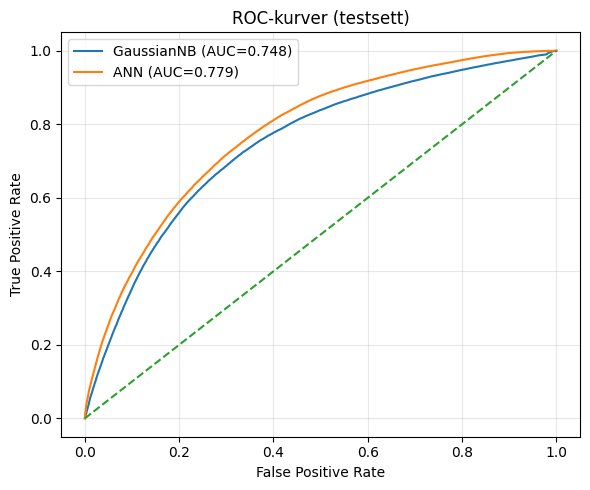

In [2]:
# === Celle 2: Tren GaussianNB + ANN, skriv ut resultater, tegn ROC-kurver ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproduserbarhet
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

# 0) GPU-sjekk (valgfritt)
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# 1) Les cache fra celle 1
NPZ_OUT = "pca_split_cache.npz"
data = np.load(NPZ_OUT)
Xp_train, Xp_test = data["Xp_train"], data["Xp_test"]
y_train, y_test   = data["y_train"],  data["y_test"]
print(f"✅ Lastet cache: Train {Xp_train.shape}, Test {Xp_test.shape}")

# 2) Baseline: Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(Xp_train, y_train)
gnb_prob = gnb.predict_proba(Xp_test)[:, 1]
gnb_pred = (gnb_prob >= 0.5).astype(int)

print("\n=== Gaussian Naive Bayes (PCA) ===")
print("Accuracy:", f"{accuracy_score(y_test, gnb_pred):.4f}")
print("ROC AUC:", f"{roc_auc_score(y_test, gnb_prob):.4f}")
print("Confusion matrix:\n", confusion_matrix(y_test, gnb_pred))
print("Classification report:\n", classification_report(y_test, gnb_pred, digits=4))

# 3) ANN (ReLU-skjulte lag, Sigmoid ut)
def build_ann(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(1, activation="sigmoid", dtype="float32"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), "accuracy"]
    )
    return model

ann = build_ann(Xp_train.shape[1])

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]

history = ann.fit(
    Xp_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    verbose=1,
    callbacks=callbacks
)

# 4) Test-evaluering ANN
ann_prob = ann.predict(Xp_test, verbose=0).ravel()
ann_pred = (ann_prob >= 0.5).astype(int)

print("\n=== Artificial Neural Network (PCA) ===")
print("Accuracy:", f"{accuracy_score(y_test, ann_pred):.4f}")
print("ROC AUC:", f"{roc_auc_score(y_test, ann_prob):.4f}")
print("Confusion matrix:\n", confusion_matrix(y_test, ann_pred))
print("Classification report:\n", classification_report(y_test, ann_pred, digits=4))

# 5) (Valgfritt) enkel terskel-tuning basert på samme val-splitt som i fit()
val_cut = int(0.8 * len(Xp_train))
val_true = y_train[val_cut:]
val_prob = ann.predict(Xp_train[val_cut:], verbose=0).ravel()

ths = np.linspace(0.2, 0.8, 301)
accs = [accuracy_score(val_true, (val_prob >= t).astype(int)) for t in ths]
best_t = ths[int(np.argmax(accs))]
ann_pred_tuned = (ann_prob >= best_t).astype(int)
print(f"\nBest threshold from val: {best_t:.3f}")
print("Tuned test accuracy:", f"{accuracy_score(y_test, ann_pred_tuned):.4f}")

# 6) ROC-kurver (begge modeller i samme plott)
fpr_g, tpr_g, _ = roc_curve(y_test, gnb_prob)
fpr_a, tpr_a, _ = roc_curve(y_test, ann_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr_g, tpr_g, label=f"GaussianNB (AUC={roc_auc_score(y_test, gnb_prob):.3f})")
plt.plot(fpr_a, tpr_a, label=f"ANN (AUC={roc_auc_score(y_test, ann_prob):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-kurver (testsett)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Lastet cache: Train (701614, 8), Test (175404, 8)
Epoch 1/40
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 22s 5ms/step - accuracy: 0.7029 - auc: 0.7694 - loss: 0.5740 - val_accuracy: 0.7000 - val_auc: 0.7713 - val_loss: 0.5776
Epoch 2/40
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.7058 - auc: 0.7739 - loss: 0.5690 - val_accuracy: 0.7014 - val_auc: 0.7721 - val_loss: 0.5747
Epoch 3/40
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 20s 5ms/step - accuracy: 0.7061 - auc: 0.7747 - loss: 0.5680 - val_accuracy: 0.7025 - val_auc: 0.7726 - val_loss: 0.5735
Epoch 4/40
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.7067 - auc: 0.7755 - loss: 0.5672 - val_accuracy: 0.7027 - val_auc: 0.7730 - val_loss: 0.5726
Epoch 5/40
4386/4386 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.7070 - auc: 0.7761 - loss: 0.5665 - val_accuracy: 0.7037 - val_auc: 0.7740 - val_loss: 0.5711
Epoch 6/40
4386/4386 ━━━━━━━━━━━━━━━━━━━━

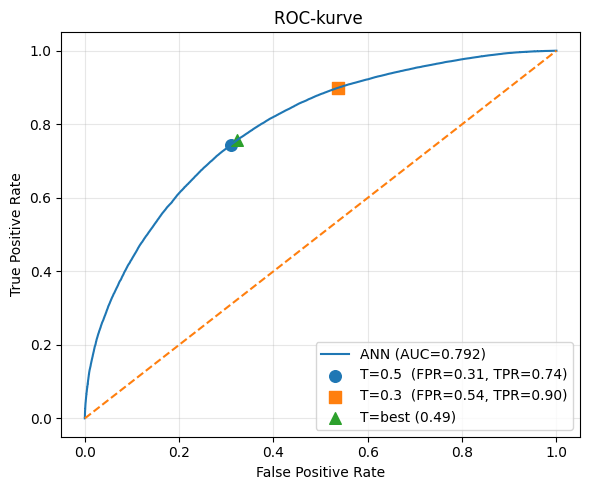

In [5]:
# === Celle 2: Tren ANN, skriv ut resultater, tegn ROC med terskelmarkører ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_score, recall_score, f1_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproduserbarhet
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

# 0) GPU-sjekk (valgfritt)
print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# 1) Les cache fra celle 1
NPZ_OUT = "pca_split_cache.npz"
data = np.load(NPZ_OUT)
Xp_train, Xp_test = data["Xp_train"], data["Xp_test"]
y_train, y_test   = data["y_train"],  data["y_test"]
print(f"✅ Lastet cache: Train {Xp_train.shape}, Test {Xp_test.shape}")

# 2) Bygg og tren ANN (ReLU-skjulte lag, Sigmoid ut)
def build_ann(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(1, activation="sigmoid", dtype="float32"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), "accuracy"]
    )
    return model

ann = build_ann(Xp_train.shape[1])

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
]

history = ann.fit(
    Xp_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=128,
    verbose=1,
    callbacks=callbacks
)

# 3) Test-evaluering (sannsynligheter + standard terskel 0.5)
ann_prob = ann.predict(Xp_test, verbose=0).ravel()

def metrics_at_threshold(y_true, prob, thr):
    pred = (prob >= thr).astype(int)
    acc = accuracy_score(y_true, pred)
    auc = roc_auc_score(y_true, prob)
    prec = precision_score(y_true, pred, zero_division=0)
    rec = recall_score(y_true, pred, zero_division=0)
    f1 = f1_score(y_true, pred, zero_division=0)
    cm = confusion_matrix(y_true, pred)
    # FPR/TPR for markør i ROC
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return {"thr": thr, "acc": acc, "auc": auc, "prec": prec, "rec": rec, "f1": f1,
            "cm": cm, "fpr": fpr, "tpr": tpr}

# Standard terskler
res_05 = metrics_at_threshold(y_test, ann_prob, 0.5)
res_03 = metrics_at_threshold(y_test, ann_prob, 0.3)

print("\n=== ANN (PCA) @ threshold = 0.5 ===")
print(f"Accuracy: {res_05['acc']:.4f} | ROC AUC: {res_05['auc']:.4f} | Precision: {res_05['prec']:.4f} | Recall: {res_05['rec']:.4f} | F1: {res_05['f1']:.4f}")
print("Confusion matrix:\n", res_05["cm"])
print("Classification report:\n", classification_report(y_test, (ann_prob >= 0.5).astype(int), digits=4))

print("\n=== ANN (PCA) @ threshold = 0.3 ===")
print(f"Accuracy: {res_03['acc']:.4f} | ROC AUC: {res_03['auc']:.4f} | Precision: {res_03['prec']:.4f} | Recall: {res_03['rec']:.4f} | F1: {res_03['f1']:.4f}")
print("Confusion matrix:\n", res_03["cm"])
print("Classification report:\n", classification_report(y_test, (ann_prob >= 0.3).astype(int), digits=4))

# 4) (Valgfritt) enkel terskel-tuning basert på samme val-splitt som i fit()
val_cut = int(0.8 * len(Xp_train))
val_true = y_train[val_cut:]
val_prob = ann.predict(Xp_train[val_cut:], verbose=0).ravel()

ths = np.linspace(0.2, 0.8, 301)
accs = [accuracy_score(val_true, (val_prob >= t).astype(int)) for t in ths]
best_t = ths[int(np.argmax(accs))]
res_best = metrics_at_threshold(y_test, ann_prob, best_t)

print(f"\nBest threshold from val: {best_t:.3f}")
print(f"Tuned test accuracy: {res_best['acc']:.4f} | Precision: {res_best['prec']:.4f} | Recall: {res_best['rec']:.4f} | F1: {res_best['f1']:.4f}")

# 5) ROC-kurve + markører for terskel 0.5 og 0.3
fpr, tpr, _ = roc_curve(y_test, ann_prob)
auc_val = roc_auc_score(y_test, ann_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ANN (AUC={auc_val:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

# Marker operasjonspunkter
plt.scatter(res_05["fpr"], res_05["tpr"], s=70, marker="o", label=f"T=0.5  (FPR={res_05['fpr']:.2f}, TPR={res_05['tpr']:.2f})")
plt.scatter(res_03["fpr"], res_03["tpr"], s=70, marker="s", label=f"T=0.3  (FPR={res_03['fpr']:.2f}, TPR={res_03['tpr']:.2f})")
plt.scatter(res_best["fpr"], res_best["tpr"], s=70, marker="^", label=f"T=best ({best_t:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-kurve ")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
# Lagre treningshistorikk til CSV for videre bruk
import pandas as pd

hist_df = pd.DataFrame(history.history)
hist_df.to_csv("training_log.csv", index=False)
print("✅ Lagret treningshistorikk til training_log.csv")
